<a href="https://colab.research.google.com/github/Ezhilarasi123/BERT-based-Bail-Type-Prediction-from-Indian-Court-Case-Facts/blob/main/Final_sem_project_model_fusion.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# =========================
# 0. IMPORTS
# =========================
import os
os.environ["CUDA_LAUNCH_BLOCKING"] = "1"

import torch
import torch.nn as nn
import numpy as np
import pandas as pd

from datasets import load_dataset
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, f1_score
from sklearn.utils.class_weight import compute_class_weight

from transformers import (
    AutoTokenizer,
    AutoModel,
    TrainingArguments,
    Trainer,
    EarlyStoppingCallback
)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [ ]:
# =========================
# 1. LOAD DATA
# =========================
dataset = load_dataset("SnehaDeshmukh/IndianBailJudgments-1200")
df = pd.DataFrame(dataset['train'])

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

indian_bail_judgments.csv: 0.00B [00:00, ?B/s]

Generating train split:   0%|          | 0/1200 [00:00<?, ? examples/s]

In [ ]:
# =========================
# 2. PREPROCESSING
# =========================
df["text"] = (
    df["facts"].astype(str) + " " +
    df["judgment_reason"].astype(str) + " " +
    df["legal_principles_discussed"].astype(str) + " " +
    df["summary"].astype(str)
).str.lower()

df["bail_outcome"] = df["bail_outcome"].str.lower().str.strip()
df["bail_type"] = df["bail_type"].fillna("unknown").str.lower().str.strip()

# Keep only valid types
valid_types = ["regular", "anticipatory", "interim"]
df = df[df["bail_type"].isin(valid_types)]

In [ ]:
# =========================
# 3. LABEL ENCODING
# =========================
le_outcome = LabelEncoder()
df["label_outcome"] = le_outcome.fit_transform(df["bail_outcome"])

le_type = LabelEncoder()
df["label_type"] = le_type.fit_transform(df["bail_type"])

GRANTED_LABEL = le_outcome.transform(["granted"])[0]

In [ ]:
# =========================
# 4. TRAIN-VAL SPLIT
# =========================
train_df, val_df = train_test_split(
    df,
    test_size=0.2,
    stratify=df["label_outcome"],
    random_state=42
)

# **# RoBERTa–LegalBERT Fusion**

In [ ]:
# =========================
# 5. TOKENIZERS (FIXED)
# =========================
tokenizer_bert = AutoTokenizer.from_pretrained("nlpaueb/legal-bert-base-uncased")
tokenizer_roberta = AutoTokenizer.from_pretrained("roberta-base")

def encode(texts):
    enc1 = tokenizer_bert(texts, truncation=True, padding=True, max_length=256)
    enc2 = tokenizer_roberta(texts, truncation=True, padding=True, max_length=256)
    return enc1, enc2

train_enc1, train_enc2 = encode(list(train_df["text"]))
val_enc1, val_enc2 = encode(list(val_df["text"]))

config.json: 0.00B [00:00, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/481 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

In [ ]:
# =========================
# 6. CLASS WEIGHTS
# =========================
outcome_weights = compute_class_weight(
    "balanced",
    classes=np.unique(df["label_outcome"]),
    y=df["label_outcome"]
)

type_weights = compute_class_weight(
    "balanced",
    classes=np.unique(df["label_type"]),
    y=df["label_type"]
)

outcome_weights = torch.tensor(outcome_weights, dtype=torch.float).to(device)
type_weights = torch.tensor(type_weights, dtype=torch.float).to(device)

In [ ]:
# =========================
# 7. DATASET
# =========================
class DualDataset(torch.utils.data.Dataset):
    def __init__(self, enc1, enc2, y_out, y_type):
        self.enc1 = enc1
        self.enc2 = enc2
        self.y_out = list(y_out)
        self.y_type = list(y_type)

    def __getitem__(self, idx):
        return {
            "input_ids_bert": torch.tensor(self.enc1["input_ids"][idx]),
            "attention_mask_bert": torch.tensor(self.enc1["attention_mask"][idx]),
            "input_ids_roberta": torch.tensor(self.enc2["input_ids"][idx]),
            "attention_mask_roberta": torch.tensor(self.enc2["attention_mask"][idx]),
            "labels_outcome": torch.tensor(self.y_out[idx]),
            "labels_type": torch.tensor(self.y_type[idx])
        }

    def __len__(self):
        return len(self.y_out)

train_dataset = DualDataset(train_enc1, train_enc2, train_df["label_outcome"], train_df["label_type"])
val_dataset = DualDataset(val_enc1, val_enc2, val_df["label_outcome"], val_df["label_type"])

In [ ]:
# =========================
# 8. FOCAL LOSS
# =========================
class FocalLoss(nn.Module):
    def __init__(self, alpha=None, gamma=2):
        super().__init__()
        self.alpha = alpha
        self.gamma = gamma

    def forward(self, logits, targets):
        ce = nn.CrossEntropyLoss(weight=self.alpha, reduction='none')(logits, targets)
        pt = torch.exp(-ce)
        return ((1 - pt) ** self.gamma * ce).mean()

In [ ]:
# =========================
# 9. MODEL (FIXED)
# =========================
class DualFusionModel(nn.Module):
    def __init__(self, num_out, num_type):
        super().__init__()

        self.bert = AutoModel.from_pretrained("nlpaueb/legal-bert-base-uncased")
        self.roberta = AutoModel.from_pretrained("roberta-base")

        self.fusion = nn.Sequential(
            nn.Linear(768 * 2, 512),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(512, 256),
            nn.ReLU()
        )

        self.outcome_head = nn.Linear(256, num_out)
        self.type_head = nn.Linear(256, num_type)

        self.out_loss_fn = FocalLoss(alpha=outcome_weights)
        self.type_loss_fn = FocalLoss(alpha=type_weights)

    def forward(
        self,
        input_ids_bert,
        attention_mask_bert,
        input_ids_roberta,
        attention_mask_roberta,
        labels_outcome=None,
        labels_type=None
    ):

        out1 = self.bert(input_ids=input_ids_bert, attention_mask=attention_mask_bert)
        out2 = self.roberta(input_ids=input_ids_roberta, attention_mask=attention_mask_roberta)

        cls1 = out1.last_hidden_state[:, 0, :]
        cls2 = out2.last_hidden_state[:, 0, :]

        fused = self.fusion(torch.cat([cls1, cls2], dim=1))

        logits_out = self.outcome_head(fused)
        logits_type = self.type_head(fused)

        loss = None
        if labels_outcome is not None:

            loss_out = self.out_loss_fn(logits_out, labels_outcome)

            mask = (labels_outcome == GRANTED_LABEL).float()

            loss_type_all = self.type_loss_fn(logits_type, labels_type)
            loss_type = (loss_type_all * mask).mean()

            loss = 1.5 * loss_out + 1.5 * loss_type

        return {
            "loss": loss,
            "logits_outcome": logits_out,
            "logits_type": logits_type
        }


In [ ]:
# =========================
# 10. TRAINER
# =========================
class CustomTrainer(Trainer):
    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):

        labels_outcome = inputs.pop("labels_outcome")
        labels_type = inputs.pop("labels_type")

        outputs = model(
            **inputs,
            labels_outcome=labels_outcome,
            labels_type=labels_type
        )

        return (outputs["loss"], outputs) if return_outputs else outputs["loss"]


In [ ]:
# =========================
# 11. METRICS
# =========================
def compute_metrics(eval_pred):
    outputs, labels = eval_pred

    logits_out = outputs[0]
    logits_type = outputs[1]

    preds_out = np.argmax(logits_out, axis=1)
    preds_type = np.argmax(logits_type, axis=1)

    labels_out = labels[0]
    labels_type = labels[1]

    return {
        "outcome_acc": accuracy_score(labels_out, preds_out),
        "type_acc": accuracy_score(labels_type, preds_type),
        "outcome_f1": f1_score(labels_out, preds_out, average="weighted"),
        "type_f1": f1_score(labels_type, preds_type, average="weighted")
    }


In [ ]:
# =========================
# 12. TRAINING ARGS
# =========================
training_args = TrainingArguments(
    output_dir="./results",
    learning_rate=1e-5,
    per_device_train_batch_size=2,
    per_device_eval_batch_size=2,
    num_train_epochs=5,
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    logging_steps=50
)

In [ ]:
# =========================
# 13. TRAIN
# =========================
model = DualFusionModel(
    num_out=len(le_outcome.classes_),
    num_type=len(le_type.classes_)
).to(device)

trainer = CustomTrainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=2)]
)

trainer.train()

pytorch_model.bin:   0%|          | 0.00/440M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: nlpaueb/legal-bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.decoder.bias               | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.decoder.weight             | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


model.safetensors:   0%|          | 0.00/499M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

RobertaModel LOAD REPORT from: roberta-base
Key                             | Status     | 
--------------------------------+------------+-
lm_head.dense.bias              | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
pooler.dense.weight             | MISSING    | 
pooler.dense.bias               | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Epoch,Training Loss,Validation Loss,Outcome Acc,Type Acc,Outcome F1,Type F1
1,0.956005,0.422950,0.974895,0.953975,0.974944,0.946504
2,1.276636,0.289430,0.987448,0.974895,0.987484,0.966686
3,0.832125,0.220488,0.987448,0.974895,0.987484,0.966686
4,0.453272,0.148677,0.987448,0.983264,0.987484,0.981962
5,0.000822,0.143737,0.991632,0.979079,0.991648,0.975434


TrainOutput(global_step=2385, training_loss=0.591308687134515, metrics={'train_runtime': 839.1771, 'train_samples_per_second': 5.684, 'train_steps_per_second': 2.842, 'total_flos': 0.0, 'train_loss': 0.591308687134515, 'epoch': 5.0})

In [ ]:
# Create folder
import os
os.makedirs("bail_model", exist_ok=True)

# Save model
trainer.save_model("bail_model")

# Save tokenizers
tokenizer_bert.save_pretrained("bail_model/bert")
tokenizer_roberta.save_pretrained("bail_model/roberta")

# Save label encoders
import joblib
joblib.dump(le_outcome, "bail_model/le_outcome.pkl")
joblib.dump(le_type, "bail_model/le_type.pkl")

print("✅ Model saved successfully!")

✅ Model saved successfully!


In [ ]:
!ls bail_model

bert		le_type.pkl	   roberta
le_outcome.pkl	model.safetensors  training_args.bin


In [ ]:
!zip -r bail_model.zip bail_model

  adding: bail_model/ (stored 0%)
  adding: bail_model/le_outcome.pkl (deflated 35%)
  adding: bail_model/roberta/ (stored 0%)
  adding: bail_model/roberta/tokenizer.json (deflated 82%)
  adding: bail_model/roberta/tokenizer_config.json (deflated 50%)
  adding: bail_model/model.safetensors (deflated 12%)
  adding: bail_model/bert/ (stored 0%)
  adding: bail_model/bert/tokenizer.json (deflated 71%)
  adding: bail_model/bert/tokenizer_config.json (deflated 42%)
  adding: bail_model/le_type.pkl (deflated 35%)
  adding: bail_model/training_args.bin (deflated 53%)


In [ ]:
from google.colab import files
files.download("bail_model.zip")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

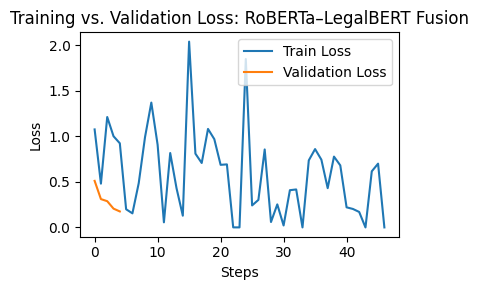

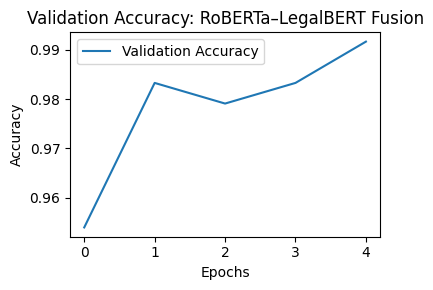

In [ ]:
# =========================
# 📊 TRAINING HISTORY PLOTS
# =========================
import matplotlib.pyplot as plt

log_history = trainer.state.log_history

train_loss = []
eval_loss = []
eval_acc = []

for log in log_history:
    if "loss" in log and "eval_loss" not in log:
        train_loss.append(log["loss"])
    if "eval_loss" in log:
        eval_loss.append(log["eval_loss"])
    if "eval_outcome_acc" in log:
        eval_acc.append(log["eval_outcome_acc"])

# Plot Loss
plt.figure(figsize=(4,3))
plt.plot(train_loss, label="Train Loss")
plt.plot(eval_loss, label="Validation Loss")
plt.xlabel("Steps")
plt.ylabel("Loss")
plt.title("Training vs. Validation Loss: RoBERTa–LegalBERT Fusion")
plt.legend()
plt.tight_layout()
plt.savefig("loss_plot.png", dpi=600)
plt.show()

# Plot Accuracy
plt.figure(figsize=(4,3))
plt.plot(eval_acc, label="Validation Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.title("Validation Accuracy: RoBERTa–LegalBERT Fusion")
plt.legend()
plt.tight_layout()
plt.savefig("accuracy_plot.png", dpi=600)
plt.show()

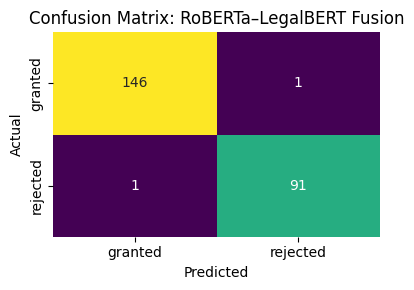

In [ ]:
import seaborn as sns
from sklearn.metrics import confusion_matrix

predictions = trainer.predict(val_dataset)

logits_out = predictions.predictions[0]
labels_out = predictions.label_ids[0]

preds_out = np.argmax(logits_out, axis=1)

cm = confusion_matrix(labels_out, preds_out)
labels = list(le_outcome.classes_)

plt.figure(figsize=(4,3))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="viridis",
    xticklabels=labels,
    yticklabels=labels,
    cbar=False
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix: RoBERTa–LegalBERT Fusion")
plt.tight_layout()
plt.savefig("cm_model.png", dpi=600)
plt.show()

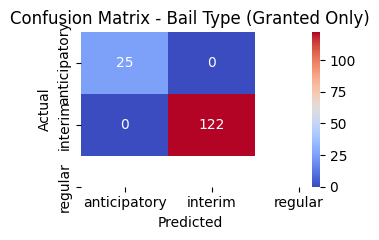

In [ ]:
# Get predictions
predictions = trainer.predict(val_dataset)

logits_type = predictions.predictions[1]
labels_type = predictions.label_ids[1]

logits_out = predictions.predictions[0]
labels_out = predictions.label_ids[0]

# Convert to predictions
preds_type = np.argmax(logits_type, axis=1)
preds_out = np.argmax(logits_out, axis=1)

# FILTER only GRANTED cases
mask = labels_out == GRANTED_LABEL

filtered_labels = labels_type[mask]
filtered_preds = preds_type[mask]

# Confusion matrix
cm_type = confusion_matrix(filtered_labels, filtered_preds)

labels = list(le_type.classes_)

plt.figure(figsize=(3.5, 2.5))

sns.heatmap(
    cm_type,
    annot=True,
    fmt="d",
    cmap="coolwarm",
    xticklabels=labels,
    yticklabels=labels
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Bail Type (Granted Only)")

plt.tight_layout()
plt.savefig("cm_type_ieee.png", dpi=300)
plt.show()

In [ ]:
metrics = trainer.evaluate()

final_results = {
    "accuracy": metrics["eval_outcome_acc"],
    "f1": metrics["eval_outcome_f1"],
    "loss": metrics["eval_loss"]
}

print("RoBERTa–LegalBERT Fusion ")
print(final_results)

RoBERTa–LegalBERT Fusion 
{'accuracy': 0.9916317991631799, 'f1': 0.9916317991631799, 'loss': 0.1763264536857605}


In [ ]:
fusion_results = final_results

In [ ]:
# =========================
# 14. PREDICTION
# =========================
def predict(text):
    model.eval()

    enc1 = tokenizer_bert(text, return_tensors="pt", truncation=True, padding=True).to(device)
    enc2 = tokenizer_roberta(text, return_tensors="pt", truncation=True, padding=True).to(device)

    with torch.no_grad():
        outputs = model(
            input_ids_bert=enc1["input_ids"],
            attention_mask_bert=enc1["attention_mask"],
            input_ids_roberta=enc2["input_ids"],
            attention_mask_roberta=enc2["attention_mask"]
        )

    out_pred = torch.argmax(outputs["logits_outcome"], dim=1).item()

    if out_pred == GRANTED_LABEL:
        type_pred = torch.argmax(outputs["logits_type"], dim=1).item()
        bail_type = le_type.inverse_transform([type_pred])[0]
    else:
        bail_type = "not_applicable"

    return {
        "bail_outcome": le_outcome.inverse_transform([out_pred])[0],
        "bail_type": bail_type
    }

In [ ]:
# =========================
# 15. TEST
# =========================
sample = "The accused is suffering from serious medical condition and needs treatment. Court grants interim relief."

print(predict(sample))

{'bail_outcome': 'granted', 'bail_type': 'regular'}


In [ ]:
test3 = "The accused is charged under IPC 302 for murder with strong eyewitness testimony and forensic evidence."

print(predict(test3))

{'bail_outcome': 'rejected', 'bail_type': 'not_applicable'}


In [ ]:
test1 = "The accused is suffering from a severe heart condition and requires immediate medical treatment. Continued custody may endanger life."

print(predict(test1))

{'bail_outcome': 'rejected', 'bail_type': 'not_applicable'}


# **DeBERTa–LegalBERT Fusion**

In [ ]:
# =========================
# 5. TOKENIZERS
# =========================
tokenizer_bert = AutoTokenizer.from_pretrained("nlpaueb/legal-bert-base-uncased")
tokenizer_deberta = AutoTokenizer.from_pretrained("microsoft/deberta-v3-base")

def encode(texts):
    enc1 = tokenizer_bert(texts, truncation=True, padding="max_length", max_length=256)
    enc2 = tokenizer_deberta(texts, truncation=True, padding="max_length", max_length=256)
    return enc1, enc2

train_enc1, train_enc2 = encode(list(train_df["text"]))
val_enc1, val_enc2 = encode(list(val_df["text"]))

config.json:   0%|          | 0.00/579 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/52.0 [00:00<?, ?B/s]

spm.model:   0%|          | 0.00/2.46M [00:00<?, ?B/s]

In [ ]:
# =========================
# 6. CLASS WEIGHTS
# =========================
outcome_weights = compute_class_weight(
    "balanced",
    classes=np.unique(df["label_outcome"]),
    y=df["label_outcome"]
)

type_weights = compute_class_weight(
    "balanced",
    classes=np.unique(df["label_type"]),
    y=df["label_type"]
)

outcome_weights = torch.tensor(outcome_weights, dtype=torch.float)
type_weights = torch.tensor(type_weights, dtype=torch.float)

In [ ]:
# =========================
# 7. DATASET
# =========================
class DualDataset(torch.utils.data.Dataset):
    def __init__(self, enc1, enc2, y_out, y_type):
        self.enc1 = enc1
        self.enc2 = enc2
        self.y_out = list(y_out)
        self.y_type = list(y_type)

    def __getitem__(self, idx):
        return {
            "input_ids_bert": torch.tensor(self.enc1["input_ids"][idx], dtype=torch.long),
            "attention_mask_bert": torch.tensor(self.enc1["attention_mask"][idx], dtype=torch.long),
            "input_ids_deberta": torch.tensor(self.enc2["input_ids"][idx], dtype=torch.long),
            "attention_mask_deberta": torch.tensor(self.enc2["attention_mask"][idx], dtype=torch.long),
            "labels_outcome": torch.tensor(self.y_out[idx], dtype=torch.long),
            "labels_type": torch.tensor(self.y_type[idx], dtype=torch.long)
        }

    def __len__(self):
        return len(self.y_out)

train_dataset = DualDataset(train_enc1, train_enc2, train_df["label_outcome"], train_df["label_type"])
val_dataset = DualDataset(val_enc1, val_enc2, val_df["label_outcome"], val_df["label_type"])

In [ ]:
# =========================
# 8. MODEL
# =========================
class LegalDebertaFusion(nn.Module):
    def __init__(self, num_out, num_type):
        super().__init__()

        self.bert = AutoModel.from_pretrained("nlpaueb/legal-bert-base-uncased")
        self.deberta = AutoModel.from_pretrained("microsoft/deberta-v3-base")

        self.norm_bert = nn.LayerNorm(768)
        self.norm_deberta = nn.LayerNorm(768)

        self.attention = nn.Sequential(
            nn.Linear(768 * 2, 512),
            nn.Tanh(),
            nn.Linear(512, 2),
            nn.Softmax(dim=1)
        )

        self.fusion = nn.Sequential(
            nn.Linear(768, 512),
            nn.ReLU(),
            nn.Dropout(0.4),
            nn.Linear(512, 256),
            nn.ReLU()
        )

        self.outcome_head = nn.Linear(256, num_out)
        self.type_head = nn.Linear(256, num_type)

        self.out_loss_fn = nn.CrossEntropyLoss(weight=outcome_weights)
        self.type_loss_fn = nn.CrossEntropyLoss(weight=type_weights)

    def forward(
        self,
        input_ids_bert,
        attention_mask_bert,
        input_ids_deberta,
        attention_mask_deberta,
        labels_outcome=None,
        labels_type=None
    ):

        out1 = self.bert(input_ids=input_ids_bert, attention_mask=attention_mask_bert)
        out2 = self.deberta(input_ids=input_ids_deberta, attention_mask=attention_mask_deberta)

        cls1 = out1.last_hidden_state[:, 0, :].float()
        cls2 = out2.last_hidden_state[:, 0, :].float()

        cls1 = self.norm_bert(cls1)
        cls2 = self.norm_deberta(cls2)

        combined = torch.cat([cls1, cls2], dim=1)
        weights = self.attention(combined)

        w1 = weights[:, 0].unsqueeze(1)
        w2 = weights[:, 1].unsqueeze(1)

        fused = w1 * cls1 + w2 * cls2
        fused = self.fusion(fused)

        logits_out = self.outcome_head(fused)
        logits_type = self.type_head(fused)

        loss = None
        if labels_outcome is not None:

            loss_out = self.out_loss_fn(logits_out, labels_outcome)

            mask = (labels_outcome == GRANTED_LABEL).float()

            loss_type_all = self.type_loss_fn(logits_type, labels_type)
            loss_type = (loss_type_all * mask).mean()

            loss = loss_out + loss_type

        return {
            "loss": loss,
            "logits_outcome": logits_out,
            "logits_type": logits_type
        }


In [ ]:
# =========================
# 9. TRAINER
# =========================
class CustomTrainer(Trainer):
    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):

        labels_outcome = inputs.pop("labels_outcome")
        labels_type = inputs.pop("labels_type")

        outputs = model(
            **inputs,
            labels_outcome=labels_outcome,
            labels_type=labels_type
        )

        return (outputs["loss"], outputs) if return_outputs else outputs["loss"]


In [ ]:
# =========================
# 10. METRICS
# =========================
def compute_metrics(eval_pred):
    outputs, labels = eval_pred

    logits_out = outputs[0]
    logits_type = outputs[1]

    preds_out = np.argmax(logits_out, axis=1)
    preds_type = np.argmax(logits_type, axis=1)

    labels_out = labels[0]
    labels_type = labels[1]

    return {
        "outcome_acc": accuracy_score(labels_out, preds_out),
        "type_acc": accuracy_score(labels_type, preds_type),
        "outcome_f1": f1_score(labels_out, preds_out, average="weighted"),
        "type_f1": f1_score(labels_type, preds_type, average="weighted")
    }

In [ ]:
# =========================
# 11. TRAINING ARGS
# =========================
training_args = TrainingArguments(
    output_dir="./results",
    learning_rate=2e-6,
    per_device_train_batch_size=2,
    per_device_eval_batch_size=2,
    num_train_epochs=6,
    warmup_ratio=0.1,
    weight_decay=0.01,
    max_grad_norm=1.0,
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    logging_steps=50,
    fp16=False,
    bf16=False
)


warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


In [ ]:
# =========================
# 12. TRAIN
# =========================
model = LegalDebertaFusion(
    num_out=len(le_outcome.classes_),
    num_type=len(le_type.classes_)
).to(device)

# 🔥 FORCE FLOAT32 (FIXES YOUR ERROR)
model = model.float()

trainer = CustomTrainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=2)]
)

trainer.train()

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: nlpaueb/legal-bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.decoder.weight             | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.decoder.bias               | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


pytorch_model.bin:   0%|          | 0.00/371M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/198 [00:00<?, ?it/s]

DebertaV2Model LOAD REPORT from: microsoft/deberta-v3-base
Key                                     | Status     |  | 
----------------------------------------+------------+--+-
mask_predictions.dense.bias             | UNEXPECTED |  | 
lm_predictions.lm_head.bias             | UNEXPECTED |  | 
mask_predictions.LayerNorm.weight       | UNEXPECTED |  | 
lm_predictions.lm_head.dense.weight     | UNEXPECTED |  | 
lm_predictions.lm_head.LayerNorm.bias   | UNEXPECTED |  | 
mask_predictions.classifier.bias        | UNEXPECTED |  | 
lm_predictions.lm_head.LayerNorm.weight | UNEXPECTED |  | 
mask_predictions.dense.weight           | UNEXPECTED |  | 
mask_predictions.classifier.weight      | UNEXPECTED |  | 
mask_predictions.LayerNorm.bias         | UNEXPECTED |  | 
lm_predictions.lm_head.dense.bias       | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


model.safetensors:   0%|          | 0.00/371M [00:00<?, ?B/s]

Epoch,Training Loss,Validation Loss,Outcome Acc,Type Acc,Outcome F1,Type F1
1,1.169279,1.140420,0.619247,0.799163,0.477963,0.709954
2,1.110960,0.937467,0.774059,0.799163,0.774904,0.709954
3,0.849602,0.690816,0.882845,0.866109,0.883284,0.835579
4,0.616132,0.533898,0.891213,0.945607,0.891798,0.936373
5,0.387994,0.491293,0.887029,0.937238,0.887722,0.928206
6,0.523410,0.457533,0.891213,0.937238,0.891620,0.928623


TrainOutput(global_step=2862, training_loss=0.8347825615827559, metrics={'train_runtime': 1548.5333, 'train_samples_per_second': 3.696, 'train_steps_per_second': 1.848, 'total_flos': 0.0, 'train_loss': 0.8347825615827559, 'epoch': 6.0})

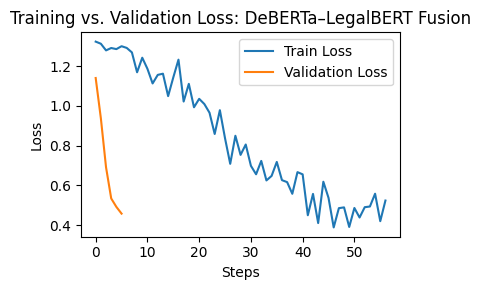

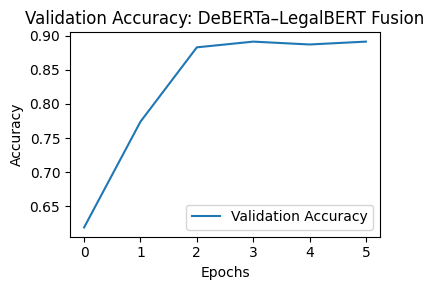

In [ ]:
# =========================
# 📊 TRAINING HISTORY PLOTS
# =========================
import matplotlib.pyplot as plt

log_history = trainer.state.log_history

train_loss = []
eval_loss = []
eval_acc = []

for log in log_history:
    if "loss" in log and "eval_loss" not in log:
        train_loss.append(log["loss"])
    if "eval_loss" in log:
        eval_loss.append(log["eval_loss"])
    if "eval_outcome_acc" in log:
        eval_acc.append(log["eval_outcome_acc"])

# Plot Loss
plt.figure(figsize=(4,3))
plt.plot(train_loss, label="Train Loss")
plt.plot(eval_loss, label="Validation Loss")
plt.xlabel("Steps")
plt.ylabel("Loss")
plt.title("Training vs. Validation Loss: DeBERTa–LegalBERT Fusion")
plt.legend()
plt.tight_layout()
plt.savefig("loss_plot.png", dpi=300)
plt.show()

# Plot Accuracy
plt.figure(figsize=(4,3))
plt.plot(eval_acc, label="Validation Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.title("Validation Accuracy: DeBERTa–LegalBERT Fusion")
plt.legend()
plt.tight_layout()
plt.savefig("accuracy_plot.png", dpi=300)
plt.show()

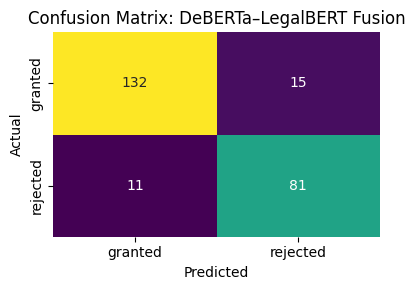

In [ ]:
import seaborn as sns
from sklearn.metrics import confusion_matrix

predictions = trainer.predict(val_dataset)

logits_out = predictions.predictions[0]
labels_out = predictions.label_ids[0]

preds_out = np.argmax(logits_out, axis=1)

cm = confusion_matrix(labels_out, preds_out)
labels = list(le_outcome.classes_)

plt.figure(figsize=(4,3))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="viridis",
    xticklabels=labels,
    yticklabels=labels,
    cbar=False
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix: DeBERTa–LegalBERT Fusion")
plt.tight_layout()
plt.savefig("cm_model.png", dpi=300)
plt.show()

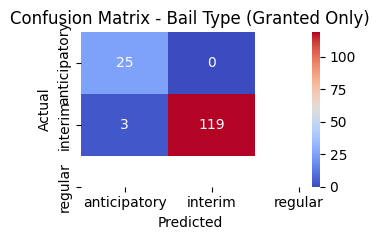

In [ ]:
# Get predictions
predictions = trainer.predict(val_dataset)

logits_type = predictions.predictions[1]
labels_type = predictions.label_ids[1]

logits_out = predictions.predictions[0]
labels_out = predictions.label_ids[0]

# Convert to predictions
preds_type = np.argmax(logits_type, axis=1)
preds_out = np.argmax(logits_out, axis=1)

# FILTER only GRANTED cases
mask = labels_out == GRANTED_LABEL

filtered_labels = labels_type[mask]
filtered_preds = preds_type[mask]

# Confusion matrix
cm_type = confusion_matrix(filtered_labels, filtered_preds)

labels = list(le_type.classes_)

plt.figure(figsize=(3.5, 2.5))

sns.heatmap(
    cm_type,
    annot=True,
    fmt="d",
    cmap="coolwarm",
    xticklabels=labels,
    yticklabels=labels
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Bail Type (Granted Only)")

plt.tight_layout()
plt.savefig("cm_type_ieee.png", dpi=300)
plt.show()

In [ ]:
metrics = trainer.evaluate()

final_results = {
    "accuracy": metrics["eval_outcome_acc"],
    "f1": metrics["eval_outcome_f1"],
    "loss": metrics["eval_loss"]
}
print("DeBERTa–LegalBERT Fusion")
print(final_results)

DeBERTa–LegalBERT Fusion
{'accuracy': 0.891213389121339, 'f1': 0.8916204410035702, 'loss': 0.4575327932834625}


In [ ]:
deberta_results = final_results

In [ ]:
# =========================
# 13. PREDICT
# =========================
def predict(text):
    model.eval()

    enc1 = tokenizer_bert(text, return_tensors="pt", truncation=True, padding="max_length").to(device)
    enc2 = tokenizer_deberta(text, return_tensors="pt", truncation=True, padding="max_length").to(device)

    with torch.no_grad():
        outputs = model(
            input_ids_bert=enc1["input_ids"],
            attention_mask_bert=enc1["attention_mask"],
            input_ids_deberta=enc2["input_ids"],
            attention_mask_deberta=enc2["attention_mask"]
        )

    out_pred = torch.argmax(outputs["logits_outcome"], dim=1).item()

    if out_pred == GRANTED_LABEL:
        type_pred = torch.argmax(outputs["logits_type"], dim=1).item()
        bail_type = le_type.inverse_transform([type_pred])[0]
    else:
        bail_type = "not_applicable"

    return {
        "bail_outcome": le_outcome.inverse_transform([out_pred])[0],
        "bail_type": bail_type
    }


In [ ]:
test1 = "The accused is suffering from a severe heart condition and requires immediate medical treatment. Continued custody may endanger life."

print(predict(test1))

{'bail_outcome': 'granted', 'bail_type': 'regular'}


In [ ]:
test3 = "The accused is charged under IPC 302 for murder with strong eyewitness testimony and forensic evidence."

print(predict(test3))

{'bail_outcome': 'granted', 'bail_type': 'regular'}


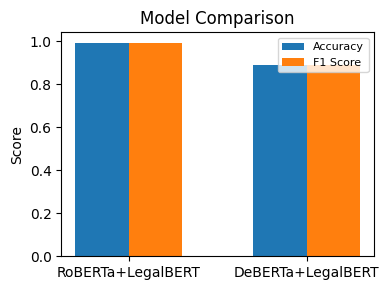

In [ ]:
models = ["RoBERTa+LegalBERT", "DeBERTa+LegalBERT"]

accuracies = [
    fusion_results["accuracy"],
    deberta_results["accuracy"]
]

f1_scores = [
    fusion_results["f1"],
    deberta_results["f1"]
]

x = np.arange(len(models))

plt.figure(figsize=(4,3))

plt.bar(x - 0.15, accuracies, width=0.3, label="Accuracy")
plt.bar(x + 0.15, f1_scores, width=0.3, label="F1 Score")

plt.xticks(x, models)
plt.ylabel("Score")
plt.title("Model Comparison")
plt.legend(fontsize=8, loc="upper right")

plt.tight_layout()
plt.savefig("model_comparison.png", dpi=600)
plt.show()